# Adaboost

In [4]:
import numpy as np
import pandas as pd
from mlxtend.plotting import plot_decision_regions

In [5]:
# data used
df = pd.DataFrame()
df['X1'] = [1,2,3,4,5,6,6,7,9,9]
df['X2'] = [5,3,6,8,1,9,5,8,9,2]
df['y'] = [1,1,0,1,0,1,0,1,0,0]

In [6]:
df

,X1,X2,y
0,1,5,1
1,2,3,1
2,3,6,0
3,4,8,1
4,5,1,0
5,6,9,1
6,6,5,0
7,7,8,1
8,9,9,0
9,9,2,0


In [7]:
import seaborn as sns

<Axes: xlabel='X1', ylabel='X2'>

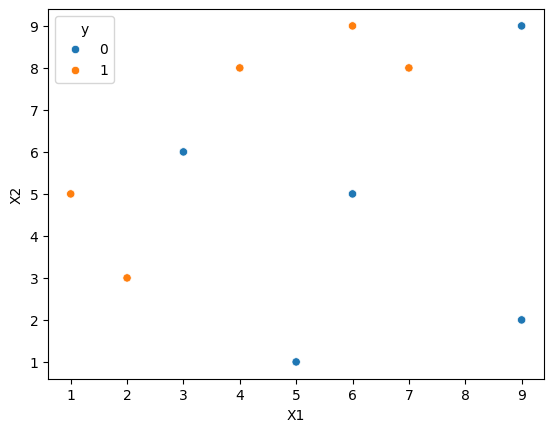

In [9]:
sns.scatterplot(x=df['X1'], y=df['X2'], hue=df['y'])

In [23]:
# Initialize the weight
df['wt'] = 1/df['X1'].shape[0]

In [24]:
df.head()

,X1,X2,y,wt
0,1,5,1,0.1
1,2,3,1,0.1
2,3,6,0,0.1
3,4,8,1,0.1
4,5,1,0,0.1


In [25]:
from sklearn.tree import DecisionTreeClassifier
dt1 = DecisionTreeClassifier(max_depth=1)

In [41]:
X = df.iloc[:, 0:2].values
y = df.iloc[:, 2].values

In [42]:
dt1.fit(X, y)

DecisionTreeClassifier(max_depth=1)

In [43]:
from sklearn.tree import plot_tree

[Text(0.5, 0.75, 'x[0] <= 2.5\ngini = 0.5\nsamples = 10\nvalue = [5, 5]'),
 Text(0.25, 0.25, 'gini = 0.0\nsamples = 2\nvalue = [0, 2]'),
 Text(0.375, 0.5, 'True  '),
 Text(0.75, 0.25, 'gini = 0.469\nsamples = 8\nvalue = [5, 3]'),
 Text(0.625, 0.5, '  False')]

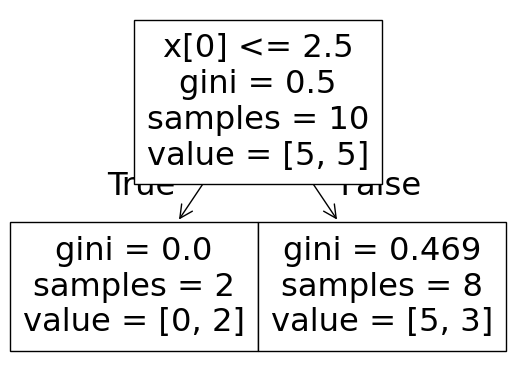

In [44]:
plot_tree(dt1)

<Axes: >

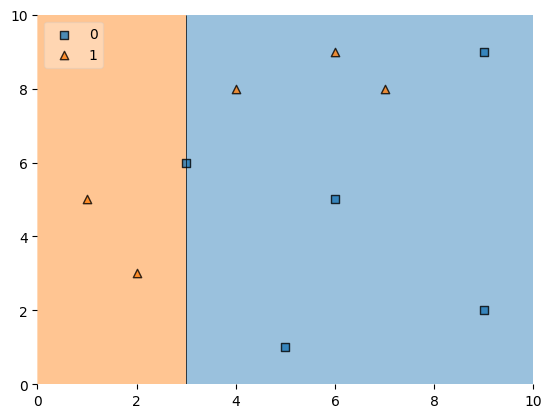

In [49]:
plot_decision_regions(X, y, clf=dt1, legend=2)

In [50]:
df['y_pred'] = dt1.predict(X)

In [51]:
df

,X1,X2,y,wt,y_pred
0,1,5,1,0.1,1
1,2,3,1,0.1,1
2,3,6,0,0.1,0
3,4,8,1,0.1,0
4,5,1,0,0.1,0
5,6,9,1,0.1,0
6,6,5,0,0.1,0
7,7,8,1,0.1,0
8,9,9,0,0.1,0
9,9,2,0,0.1,0


In [62]:
error = 0
for i in range(df.shape[0]):
    if(df['y'].values[i] != df['y_pred'].values[i]):
        error = error+df['wt'].values[i]

In [63]:
error

np.float64(0.30000000000000004)

In [64]:
def calculate_model_weight(error):
  return 0.5*np.log((1-error)/(error))

In [66]:
alpha1 = calculate_model_weight(error)
alpha1

np.float64(0.4236489301936017)

In [73]:
# update weight
def updated_weight_calculate(row, alpha=0.423):
    if(row['y']==row['y_pred']):
        return row['wt'] * np.exp(-alpha)
    else:
        return row['wt'] * np.exp(alpha)

In [74]:
df['udated_wieght'] = df.apply(updated_weight_calculate, axis=1)

In [75]:
df

,X1,X2,y,wt,y_pred,udated_wieght
0,1,5,1,0.1,1,0.065508
1,2,3,1,0.1,1,0.065508
2,3,6,0,0.1,0,0.065508
3,4,8,1,0.1,0,0.152653
4,5,1,0,0.1,0,0.065508
5,6,9,1,0.1,0,0.152653
6,6,5,0,0.1,0,0.065508
7,7,8,1,0.1,0,0.152653
8,9,9,0,0.1,0,0.065508
9,9,2,0,0.1,0,0.065508


In [76]:
df['normalize_weight'] = df['udated_wieght']/df['udated_wieght'].sum()

In [77]:
df

,X1,X2,y,wt,y_pred,udated_wieght,normalize_weight
0,1,5,1,0.1,1,0.065508,0.071475
1,2,3,1,0.1,1,0.065508,0.071475
2,3,6,0,0.1,0,0.065508,0.071475
3,4,8,1,0.1,0,0.152653,0.166559
4,5,1,0,0.1,0,0.065508,0.071475
5,6,9,1,0.1,0,0.152653,0.166559
6,6,5,0,0.1,0,0.065508,0.071475
7,7,8,1,0.1,0,0.152653,0.166559
8,9,9,0,0.1,0,0.065508,0.071475
9,9,2,0,0.1,0,0.065508,0.071475


In [79]:
df['cumsum_upper'] = np.cumsum(df['normalize_weight'])
df['cumsum_lower'] = df['cumsum_upper'] - df['normalize_weight']

In [89]:
def create_newdata(df):
    indices = []
    for i in range(df.shape[0]):
        a = np.random.random()
        for index, row in df.iterrows():
            if row['cumsum_upper'] > a and a > row['cumsum_lower']:
                indices.append(index)
    return indices

In [90]:
index_value = create_newdata(df)

In [91]:
index_value

[3, 0, 2, 4, 1, 3, 7, 8, 7, 6]

In [93]:
second_df = df.iloc[index_value,[0,1,2,3]]

In [94]:
second_df

,X1,X2,y,wt
3,4,8,1,0.1
0,1,5,1,0.1
2,3,6,0,0.1
4,5,1,0,0.1
1,2,3,1,0.1
3,4,8,1,0.1
7,7,8,1,0.1
8,9,9,0,0.1
7,7,8,1,0.1
6,6,5,0,0.1


In [95]:


dt2 = DecisionTreeClassifier(max_depth=1)
     

X = second_df.iloc[:,0:2].values
y = second_df.iloc[:,2].values
     

dt2.fit(X,y)
     


DecisionTreeClassifier(max_depth=1)

[Text(0.5, 0.75, 'x[1] <= 7.0\ngini = 0.48\nsamples = 10\nvalue = [4, 6]'),
 Text(0.25, 0.25, 'gini = 0.48\nsamples = 5\nvalue = [3, 2]'),
 Text(0.375, 0.5, 'True  '),
 Text(0.75, 0.25, 'gini = 0.32\nsamples = 5\nvalue = [1, 4]'),
 Text(0.625, 0.5, '  False')]

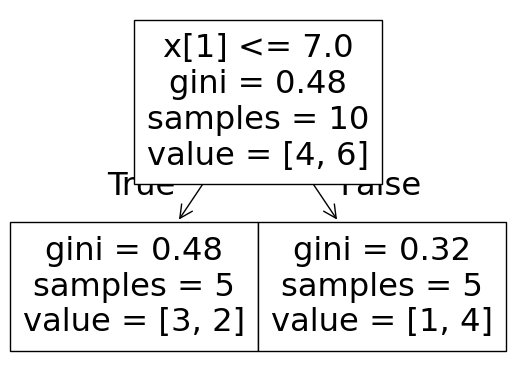

In [96]:
plot_tree(dt2)

<Axes: >

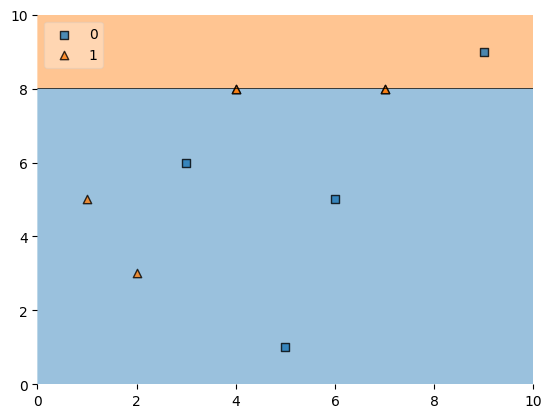

In [97]:
plot_decision_regions(X, y, clf=dt2, legend=2)

In [98]:


second_df['y_pred'] = dt2.predict(X)
     

second_df
     


,X1,X2,y,wt,y_pred
3,4,8,1,0.1,1
0,1,5,1,0.1,0
2,3,6,0,0.1,0
4,5,1,0,0.1,0
1,2,3,1,0.1,0
3,4,8,1,0.1,1
7,7,8,1,0.1,1
8,9,9,0,0.1,1
7,7,8,1,0.1,1
6,6,5,0,0.1,0


In [99]:
alpha2 = calculate_model_weight(0.1)

In [103]:
def update_row_weights(row,alpha=1.09):
  if row['y'] == row['y_pred']:
    return row['wt'] * np.exp(-alpha)
  else:
    return row['wt'] * np.exp(alpha)
     


In [104]:
second_df['updated_weight'] = second_df.apply(update_row_weights,axis=1)

In [106]:
second_df['nomalized_weights'] = second_df['updated_weight']/second_df['updated_weight'].sum()

In [108]:
second_df['cumsum_upper'] = np.cumsum(second_df['nomalized_weights'])
second_df['cumsum_lower'] = second_df['cumsum_upper'] - second_df['nomalized_weights']
     


In [110]:


index_values = create_newdata(second_df)
     

third_df = second_df.iloc[index_values,[0,1,2,3]]
     


# prediction



query = np.array([1,5]).reshape(1,2)
dt1.predict(query)
     

array([1])


dt2.predict(query)
     

array([1])


dt3.predict(query)
     

array([1])


alpha1*1 + alpha2*(1) + alpha3*(1)
     

1.09861228866811


np.sign(1.09)
     

1.0


query = np.array([9,9]).reshape(1,2)
dt1.predict(query)
     

array([1])


# Adaboost using sklearn

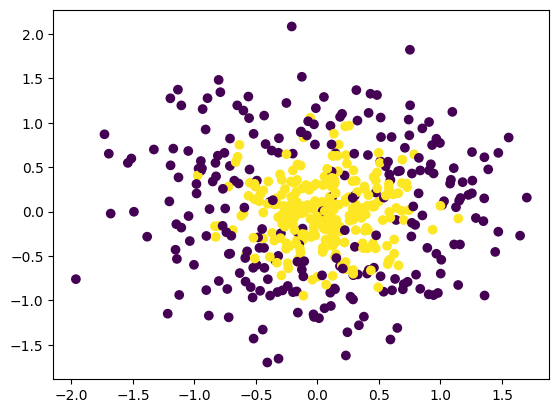

In [111]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from mlxtend.plotting import plot_decision_regions
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_circles

np.random.seed(42)
X, y = make_circles(n_samples=500, factor=0.1, noise=0.35, random_state=42)
#X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

plt.scatter(X[:,0],X[:,1],c=y)


In [112]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.model_selection import cross_val_score

abc = AdaBoostClassifier()

np.mean(cross_val_score(abc,X,y,scoring='accuracy',cv=10))

np.float64(0.812)

In [113]:
abc.fit(X,y)

AdaBoostClassifier()

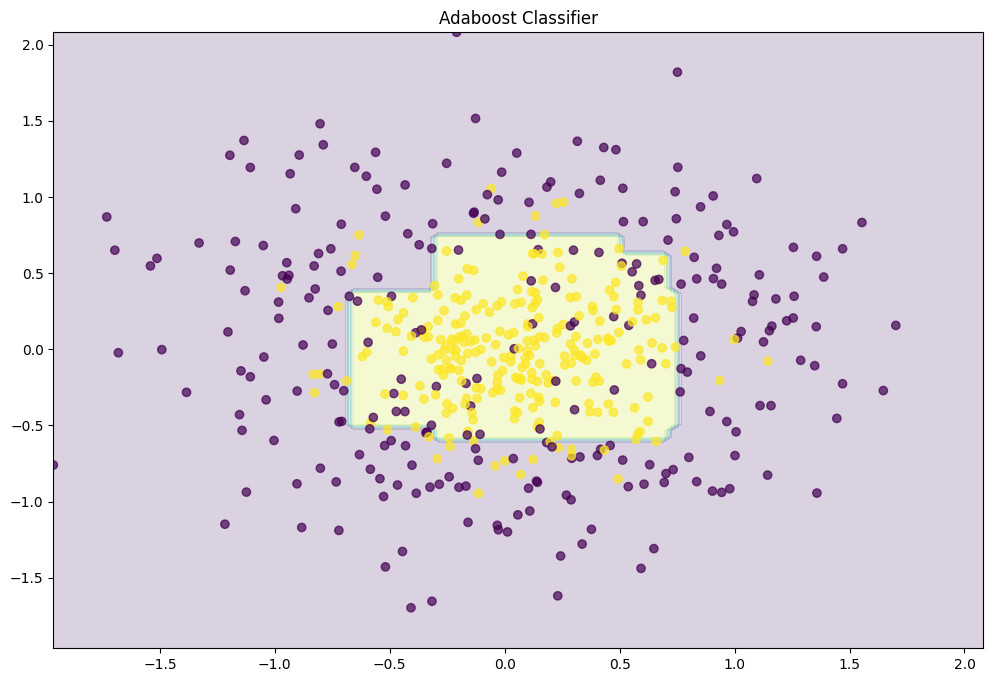

In [114]:
def plot_decision_boundary(clf):
    plt.figure(figsize=(12, 8))
    x_range = np.linspace(X.min(), X.max(), 100)
    xx1, xx2 = np.meshgrid(x_range, x_range)
    y_hat = clf.predict(np.c_[xx1.ravel(), xx2.ravel()])
    y_hat = y_hat.reshape(xx1.shape)
    plt.contourf(xx1, xx2, y_hat, alpha=0.2)
    plt.scatter(X[:,0], X[:,1], c=y, cmap='viridis', alpha=.7)
    plt.title("Adaboost Classifier")
    plt.show()
    
plot_decision_boundary(abc)

In [ ]:
from sklearn.model_selection import GridSearchCV

grid = dict()
grid['n_estimators'] = [10, 50, 100, 500]
grid['learning_rate'] = [0.0001, 0.001, 0.01, 0.1, 1.0]
grid['algorithm'] = ['SAMME', 'SAMME.R']


grid_search = GridSearchCV(estimator=AdaBoostClassifier(), param_grid=grid, n_jobs=-1, cv=10, scoring='accuracy')
# execute the grid search
grid_result = grid_search.fit(X, y)
# summarize the best score and configuration
print("Best: %f using %s" % (grid_result.best_score_, grid_result.best_params_))

/home/master/python/MachineLeaning/venv3/lib/python3.11/site-packages/sklearn/ensemble/_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(
/home/master/python/MachineLeaning/venv3/lib/python3.11/site-packages/sklearn/ensemble/_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(
/home/master/python/MachineLeaning/venv3/lib/python3.11/site-packages/sklearn/ensemble/_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(
/home/master/python/MachineLeaning/venv3/lib/python3.11/site-packages/sklearn/ensemble/_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(
/home/master/python/